# Custom implementation of *A Low-Complexity Quantum Principal Component Analysis Algorithm*
https://doi.org/10.1109/TQE.2021.3140152

In [67]:
import numpy as np
import pandas as pd
import itertools


#i replace the linear solver from quantum algorithms NUMPYMAtrix to operator a more recent appraoch to 
#This represents a matrix operator that will evolve() a Statevector ∣ψ⟩ by matrix-vector multiplication

from qiskit.quantum_info import Operator
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator #change AEr to Aer simulator 
from qiskit_aer import StatevectorSimulator
from qiskit import QuantumRegister, QuantumCircuit 
#from qiskit import Aer, QuantumRegister, QuantumCircuit #the AER transpiler needs to be imported with the most recent 
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import phase_estimation

#rom qiskit.circuit.library import PhaseEstimation
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.circuit.library.data_preparation import StatePreparation

import warnings
warnings.filterwarnings("ignore")

### Utils

In [68]:
def Generate_matrix(replicate_paper, matrix_dimension, eig_values_list=None):
    """
    Synthetic matrix generator through input parameters: 
        -   replicate_paper: boolean parameter, recreate 2x2 matrix used in reference paper
        -   matrix_dimension: int parameter for synthetic matrix generation
        -   eig_values_list: optional eigenvalues list. if not provided, it will be calculated from generated matrix.
    Output :
        - synthetic matrix as numpy matrix.
        - normalization factor
    """

    if replicate_paper == False:
        # Generate hermitian matrix
        random_matrix=np.random.rand(matrix_dimension, matrix_dimension) 
        hermitian_matrix=np.dot(random_matrix, random_matrix.T)

        eig, e_v = np.linalg.eig(hermitian_matrix)
        if eig_values_list is None:
            eig_values_list = np.array(eig)

        example_matrix = e_v @ np.diag(eig_values_list) @ e_v.T

    else:
        example_matrix = np.array([[1.5, 0.5],[0.5, 1.5]])
    
    norm_factor = np.trace(example_matrix)
    normalized_example_matrix = example_matrix/norm_factor

    print(f'Matrix:\n {example_matrix.round(2)}\n')
    for eigenval, eigenvec in zip(np.linalg.eig(example_matrix)[0][::-1], np.rot90(np.linalg.eig(example_matrix)[1])):
        print(f'eigenvalue: {eigenval:.0f} - eigenvector: {eigenvec.round(3)}')
    return normalized_example_matrix, norm_factor

In [69]:
#computing the thetas
def thetas_computation(example_matrix, debug = False):
    """
    For a generic matrix, the corrisponding quantum state is generated through a binary tree, whose internal nodes store the amplitudes of the state. 
    The following function extract thetas,through binary tree calculation, used to construct the quantum circuit employed to encode the original information in qubits.  

    Input parameters: 
        -   example_matrix: generic matrix as numpy matrix.
    Output :
        - thetas : list of computed thetas.
        - all_combination: list combination of base state vectors.
    """
    lst_combination=[]
    
    #1 STEP: INPUT_PROBABILITIES COMPUTATION
    sum_squares = (example_matrix**2).sum()
    input_probabilities = (example_matrix**2/sum_squares).flatten()

    #2 STEP: BINARY TREE - NODES COMPUTATION
    for k in range(1, int(np.ceil(np.log2(len(example_matrix)**2)))+1):
        lst_combination.append(list(map(list, itertools.product([0, 1], repeat=k))))
    container=[]
    for lst in lst_combination:
        container.append([''.join([''.join(str(j)) for j in i]) for i in lst])
    all_combinations=[item for c in container for item in c]

    general_bitstring=[''.join([''.join(str(j)) for j in i]) for i in list(map(list, itertools.product([0, 1], repeat=int(np.ceil(np.log2(len(example_matrix)**2))))))][:len(input_probabilities)]
    
    #Nodes contains all the values of the tree (except for the root)
    nodes=[]
    for st in all_combinations:
        #print(st)
        starts = [general_bitstring.index(l) for l in general_bitstring if l.startswith(st)]
        #print(starts)
        if debug == True:
            print(st,'->',np.sqrt(input_probabilities[starts].sum()))
        nodes.append(np.sqrt(input_probabilities[starts].sum()))
    
    #add root tree
    nodes.insert(0, 1)
    
    #3 STEP: BINARY TREE - THETAS COMPUTATION
    thetas=[]

    idx=0
    for i in range(1,len(nodes),2):
        
        right_node=i
        left_node=right_node+1
        if nodes[idx]!=0:
            thetas.append(2*np.arccos(nodes[right_node]/nodes[idx]))
            thetas.append(2*np.arcsin(nodes[left_node]/nodes[idx]))
        else:
            thetas.append(0)
            thetas.append(0)

        idx+=1
    return thetas, all_combinations

In [70]:
def generate_qram_circuit(thetas, all_combinations, example_matrix):
    """
    For a generic matrix, the corrisponding qram circuit for matrix preprocessing into corrisponding quantum state. 

    Input parameters: 
        - example_matrix: generic matrix as numpy matrix.
        - thetas : list of computed thetas.
        - all_combination: list combination of base state vectors.
    Output :
        - qc : preprocessing circuit.
    """
    right_nodes_indexes=list(range(0,len(thetas),2))
    rotations_list=list(zip(np.array(all_combinations)[right_nodes_indexes],np.array(thetas)[right_nodes_indexes]))

    qc=QuantumCircuit(int(np.ceil(np.log2(len(example_matrix)**2))))

    for r_l in rotations_list:
        target_qubit=len(r_l[0])-1
        
        #First case of R_0
        if target_qubit==0:
            qc.ry(theta=r_l[1],qubit=target_qubit)
            continue
            
        not_gate=[]
        for qb in range(target_qubit):
            if r_l[0][qb]=='0':
                not_gate.append(qb)
                
        c_t_qubits=list(range(len(r_l[0])))
        n_controls=len(range(target_qubit))
        
        if len(not_gate)>0:
            qc.x(not_gate)
            c_ry = RYGate(r_l[1]).control(n_controls)
            qc.append(c_ry, c_t_qubits)
            qc.x(not_gate)
        else:
            c_ry = RYGate(r_l[1]).control(n_controls)
            qc.append(c_ry, c_t_qubits)
    return qc

In [71]:
from scipy.linalg import expm 
from qiskit.circuit.library import QFTGate

def my_phase_estimation(matrix, qram_circuit, resolution):
    
    # Create the unitary operator using matrix exponential
    U = expm(2j * np.pi * example_matrix)
    #U = expm(matrix * (2 * np.pi * 1j/4))   #not sure if im meant to normalize it here or not  

    # Create the Operator object from U operator using the operator class from qiskit 
    u_operator = Operator(U)
    
    # Convert the operator to a UnitaryGate
    u_gate = u_operator.to_instruction()

    # Print dimensions for debugging because of the problem with the circuit misaligment with QRAM 
    print(f"Matrix dimensions: {matrix.shape}")
    print(f"Unitary gate qubits: {u_gate.num_qubits}")
    print(f"QRAM circuit qubits: {qram_circuit.num_qubits}")
    
    # Create registers matching QRAM circuit size
    eval_register = QuantumRegister(resolution, 'eval')
    state_register = QuantumRegister(qram_circuit.num_qubits, 'state')
    
    # Create the main circuit with both registers
    pe_circuit = QuantumCircuit(eval_register, state_register)
    
    # First prepare the state using the QRAM circuit
    pe_circuit.append(qram_circuit.to_gate(), state_register)
    
    # Apply the phase estimation algorithm manually
    # Step 1: Apply Hadamard to all evaluation qubits
    for i in range(resolution):
        pe_circuit.h(eval_register[i])
    
    # Step 2: Apply controlled-unitary operations with increasing powers
    for i in range(resolution):
        # Apply 2^i controlled applications of the unitary 
        # Make sure we're applying to the right number of qubits
        control_qubit = [eval_register[i]]
        target_qubits = list(state_register)
        
        # create a controlled version of the unitary that matches the state register size
        if u_gate.num_qubits != len(target_qubits):
            # create a unitary that matches our state register size
            expanded_unitary = np.kron(U, np.eye(2**(len(target_qubits) - u_gate.num_qubits)))
            controlled_u = Operator(expanded_unitary).to_instruction().control(1)
        else:
            controlled_u = u_gate.control(1)
        
        for _ in range(2**i):
            pe_circuit.append(controlled_u, control_qubit + target_qubits)
    
    # Apply inverse QFT to the evaluation register 
    from qiskit.circuit.library import QFTGate
    pe_circuit.append(QFTGate(resolution).inverse(), eval_register)
    
    return pe_circuit

def check_statevector(backend, pe_circuit, resolution, example_matrix):
    pe_job = backend.run(transpile(pe_circuit, backend=backend))
    statevector = np.asarray(pe_job.result().get_statevector()).round(3)

    bitstrings = [''.join([''.join(str(j)) for j in i]) for i in list(map(list, itertools.product([0, 1], repeat=resolution+len(example_matrix))))]
    statevector_dict = {}
    for bitstring, amplitude in zip(bitstrings, statevector):
        statevector_dict[bitstring] = amplitude
    return statevector_dict

In [72]:
from scipy.signal import find_peaks
def eigen_estimation(probabilities, sign_dictionary, resolution, debug=True):
    """
    Estimate eigenvalues and eigenvectors from the input matrix and the relative output of state tomography 

    Input parameters: 
        - probabilities: the probabilities for each state obtained from tomography
        - sign dictionary: the signs of the reconstructed (via tomography) statevector
        - resolution: number of qubits used to represent the computed eigenvalues
    Output :
        - eigenvalues: eigenvalues of the input matrix
        - eigenvectors: eigenvectors of the input matrix
    """
    raw_results = []  # Store intermediate results
    
    for bitstring, prob in probabilities.items():
        if bitstring in sign_dictionary:
            raw_results.append((bitstring, prob))
    
    if debug:
        print("Raw eigen_estimation intermediate results:", raw_results)
    
    df = pd.DataFrame.from_dict(probabilities, orient='index')
    df.reset_index(inplace=True)
    df.columns=['state', 'module']

    df['lambda']=df['state'].apply(lambda x: x[-resolution:])
    df1=df.groupby('lambda').agg({'module':'sum'})
    #df1['module_new']=df1['module'].apply(lambda x: np.sqrt(x.real**2 + x.imag**2))
    df1=df1.sort_values('module',ascending=False)
    df1.reset_index(inplace=True)
    df1['num']=df1['lambda'].apply(lambda x :int(x[::-1],base=2)/(2**resolution))

    peaks=[]
    nums_peaks=[]

    for i in find_peaks(df1.sort_values(['num'])['module'], threshold=0.001)[0]:
        el = df1.sort_values(['num']).iloc[i]
        nums_peaks.append(el['num'])
        peaks.append(el['lambda'])

    if debug == True:
        print(peaks, nums_peaks)
        df1[['num','module']].sort_values('num').set_index('num').plot(style='-*',figsize=(15,10))

    df.columns=['state','module','lambda']
    df['sign']=np.array(list(sign_dictionary.values()))
    df['module']=df['module'].multiply(np.array(list(sign_dictionary.values())), axis=0)
    df=df.fillna(0)

    a=[]
    save_sign=[]
    eigenvalues=[]
    for l in peaks:
        eigenvalues.append(int(l[::-1],base=2)/(2**resolution))
        a_=np.array(df.query("state.str.endswith(@l)")['module'].values)
        #print(a_)
        save_sign.append(np.sign(a_))
        #print(save_sign)
        
        a.append(np.sqrt(abs(a_)))

    #a=[a1,a2]

    for i in range(len(a)):
        print(a[i])
        normalization_factor=np.sqrt((1/(sum(a[i]**2))))
        print(normalization_factor)
        a[i]*=normalization_factor
        a[i]*=save_sign[i]

    len_eigenvector = len(list(probabilities.keys())[0])-resolution
    eigenvectors=[]
    for ll, eig in zip(a, eigenvalues):
        
        eigenvector=np.zeros(len_eigenvector) #put length of eigenvector
        save_sign=np.sign(ll)
        sv=abs(ll)
        max_list=[]
        scaled_statevectors=[]
        for e,i in enumerate(range(0,len(sv), len_eigenvector)):
            max_list.append(max(sv[i:i+len_eigenvector]))
            scaled_statevectors.append(sv[i:i+len_eigenvector]/max_list[e])
            print(max_list,scaled_statevectors)
        idx_max=np.argmax(max_list)
        print(idx_max)
        max_max=max_list[idx_max]
        print(max_max)
        value=np.sqrt(max_max)
        eigenvector=scaled_statevectors[idx_max]*value*save_sign[:len(example_matrix)]
        eigenvector=scaled_statevectors[idx_max]*value*save_sign[len_eigenvector*idx_max:len_eigenvector*idx_max+len_eigenvector]
        eigenvectors.append((eig, eigenvector))

    return eigenvectors

In [73]:
def sign_estimation(pe_circuit, probabilities, n_shots):
    """
    Estimate signs for the circuit's statevector

    Input parameters: 
        - pe_circuit: circuit that performs phase estimation
        - probabilities: the probabilities for each state obtained from tomography
        - n_shots: number of shots
    Output :
        - sign_dictionary: dictionary containing the signs
    """

    # Create the first operator for tomography
    pe_circuit.remove_final_measurements()
    op_U = pe_circuit.to_gate(label='op_U').control()
    #Create the second operator for tomography
    op_V = StatePreparation(np.sqrt(list(probabilities.values())),label='c_V').control()

    qr_target = QuantumRegister(pe_circuit.num_qubits, 'target')
    qr_control = QuantumRegister(1, 'control_qubit')

    sign_estimation_circuit = QuantumCircuit(qr_target, qr_control, name='sign_estimation')
    sign_estimation_circuit.h(qr_control)
    sign_estimation_circuit.x(qr_control)

    sign_estimation_circuit.append(op_U, qr_control[:]+qr_target[:])
    sign_estimation_circuit.x(qr_control)
    sign_estimation_circuit.append(op_V, qr_control[:]+qr_target[:])
    sign_estimation_circuit.h(qr_control)
    sign_estimation_circuit.measure_all()

    backend_simulation = AerSimulator()  # This creates a QASM simulator by default
    job_for_sign = backend_simulation.run(transpile(sign_estimation_circuit, backend_simulation), shots=n_shots)
    counts_for_sign = job_for_sign.result().get_counts()

    #Take only counts with control qubits equal to 0
    tmp=np.zeros(2**pe_circuit.num_qubits)
    for c in counts_for_sign:
        if c[0]=='0':
            tmp[int(c[1:],2)]=counts_for_sign[c]

    #Sign estimation
    sign_dictionary={}
    sign=0
    for e, (count, prob) in enumerate(zip(tmp, probabilities.values())):
        if count>0.4*prob*n_shots:
            sign=1
        else:
            sign=-1
        if prob==0:
            sign=1
        sign_dictionary.update({bin(e)[2:].zfill(pe_circuit.num_qubits):sign})
    print("Processing probabilities:", len(probabilities))
    print("Sign dictionary entries:", len(sign_dictionary))
    return sign_dictionary

In [74]:
# Function constructed from the scipy pca class
def transform(original_matrix, eigenvalues, components):
    
    components = np.array(components)
    X_transformed = np.dot(original_matrix, components.T)
    X_transformed /= np.sqrt(eigenvalues)

    return X_transformed

## Main

#### Generate synthetic data

In [75]:
# Change this to False to generate a random matrix with choosen eigenvalues
replicate_paper = True
# Desired eigenvalues for the synthetic matrix
eigval_list = np.array([1, 4])
example_matrix, norm_factor = Generate_matrix(replicate_paper, matrix_dimension = 2, eig_values_list = eigval_list)

big_matrix = np.copy(example_matrix)

Matrix:
 [[1.5 0.5]
 [0.5 1.5]]

eigenvalue: 1 - eigenvector: [-0.707  0.707]
eigenvalue: 2 - eigenvector: [0.707 0.707]


as an example, we take the 2x2 matrix used in the original paper
$$
A_0=\left[\begin{array}{ll}
1.5 & 0.5 \\
0.5 & 1.5
\end{array}\right]
$$

whose quantum state is given by
$$\left|\psi_{A_0}\right\rangle=\frac{3}{\sqrt{20}}|00\rangle+\frac{1}{\sqrt{20}}|01\rangle+\frac{1}{\sqrt{20}}|10\rangle+\frac{3}{\sqrt{20}}|11\rangle .$$

$20$ derives from $3^2 + 1^2 + 1^2 + 3^2$ and is necessary for normalization

#### Preprocessing 

In [76]:
# Preprocessing circuit
#import matplotlib.pyplot as plt
import pylatexenc
%matplotlib inline 
import matplotlib.pyplot as plt 
from IPython import display 
from qiskit.visualization import circuit_drawer

def visualize_quantum_circuit(circuit, figsize=(12, 6), scale=0.7):
    """Helper function to visualize quantum circuits with consistent styling"""
    try:
        fig, ax = plt.subplots(figsize=figsize)
        # Return the figure object from circuit_drawer
        circuit_drawing = circuit_drawer(circuit, output='mpl', scale=scale, ax=ax)
        plt.tight_layout()
        return circuit_drawing  # Return the figure for display
    except Exception as e:
        print(f"Visualization error: {e}")
        # Try text output as fallback
        print("Fallback to text representation:")
        print(circuit)
    finally:
        plt.close(fig)
   

# Configure Jupyter

plt.style.use('default')

# Generate and visualize circuit
thetas, all_combinations = thetas_computation(example_matrix, debug=False)
matrix_circuit = generate_qram_circuit(thetas, all_combinations, example_matrix)

# Display the circuit
fig = visualize_quantum_circuit(matrix_circuit)
if fig is not None:  # Only try to display if we got a figure back
    display.display(fig)


In [77]:
#from qiskit_aer.primitives import StatevectorEstimator
from qiskit.quantum_info import Statevector


simulator = AerSimulator(method='statevector')
matrix_circuit_with_measure = matrix_circuit.copy()
matrix_circuit_with_measure.measure_all()
job = simulator.run(transpile(matrix_circuit_with_measure, simulator))
counts = job.result().get_counts()
print("Counts:", counts)

Counts: {'01': 54, '00': 474, '11': 453, '10': 43}


In [78]:
# Replace the existing simulator code with this
from qiskit.quantum_info import Statevector

# Generate and get the statevector directly
thetas, all_combinations = thetas_computation(example_matrix, debug=False)
matrix_circuit = generate_qram_circuit(thetas, all_combinations, example_matrix)

# Get the statevector directly from the circuit
state = Statevector.from_instruction(matrix_circuit)
statevector = state.data

# Now you can use the statevector
print("Statevector shape:", statevector.shape)
print("First few amplitudes:", statevector[:4])


Statevector shape: (4,)
First few amplitudes: [0.67082039+0.j 0.2236068 +0.j 0.2236068 +0.j 0.67082039+0.j]


Matrix dimensions: (2, 2)
Unitary gate qubits: 1
QRAM circuit qubits: 2
Figure(1512.73x451.5)


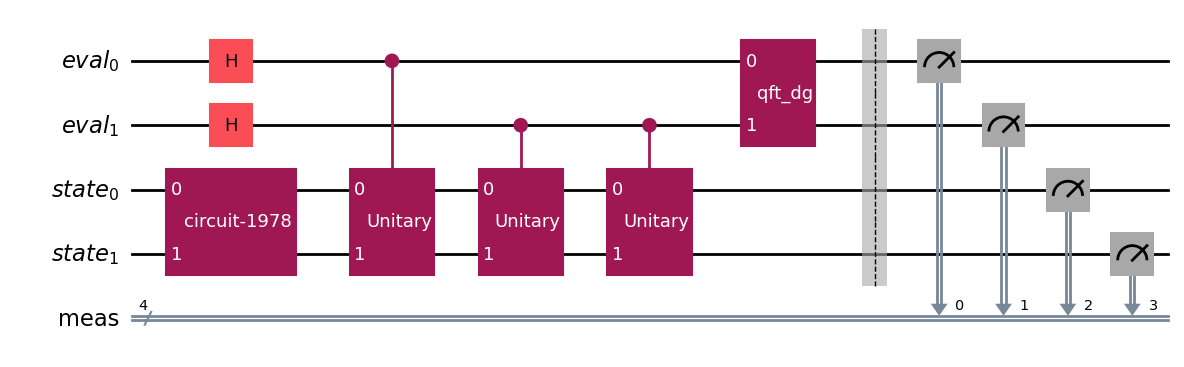

In [79]:
# Create and Add Phase estimation block to circuit
resolution = 2 #this can be played wait 
pe_circuit = my_phase_estimation(example_matrix, matrix_circuit, resolution)
pe_circuit.measure_all()

# For running the simulation with measurements
print(pe_circuit.draw('mpl'))


# Create the simulator properly for Qiskit 1.4.1
from qiskit_aer import AerSimulator
backend_simulation = AerSimulator()  # Use the default method

# Run the simulation
n_shots = 50000 #change the shots maybe 
job = backend_simulation.run(transpile(pe_circuit, backend_simulation), shots=n_shots) # uughhhhhhhhhhh backend simulation no longer exists like this 
counts = job.result().get_counts()

#### Phase Estimation

In [80]:
# Create and Add Phase estimation block to circuit
resolution = 5 #this will give us too many estimates, change this based on the matrix size 
pe_circuit = my_phase_estimation(example_matrix, matrix_circuit, resolution)

Matrix dimensions: (2, 2)
Unitary gate qubits: 1
QRAM circuit qubits: 2


pylatexenc version: 2.10
Figure(2265.23x2959.83)


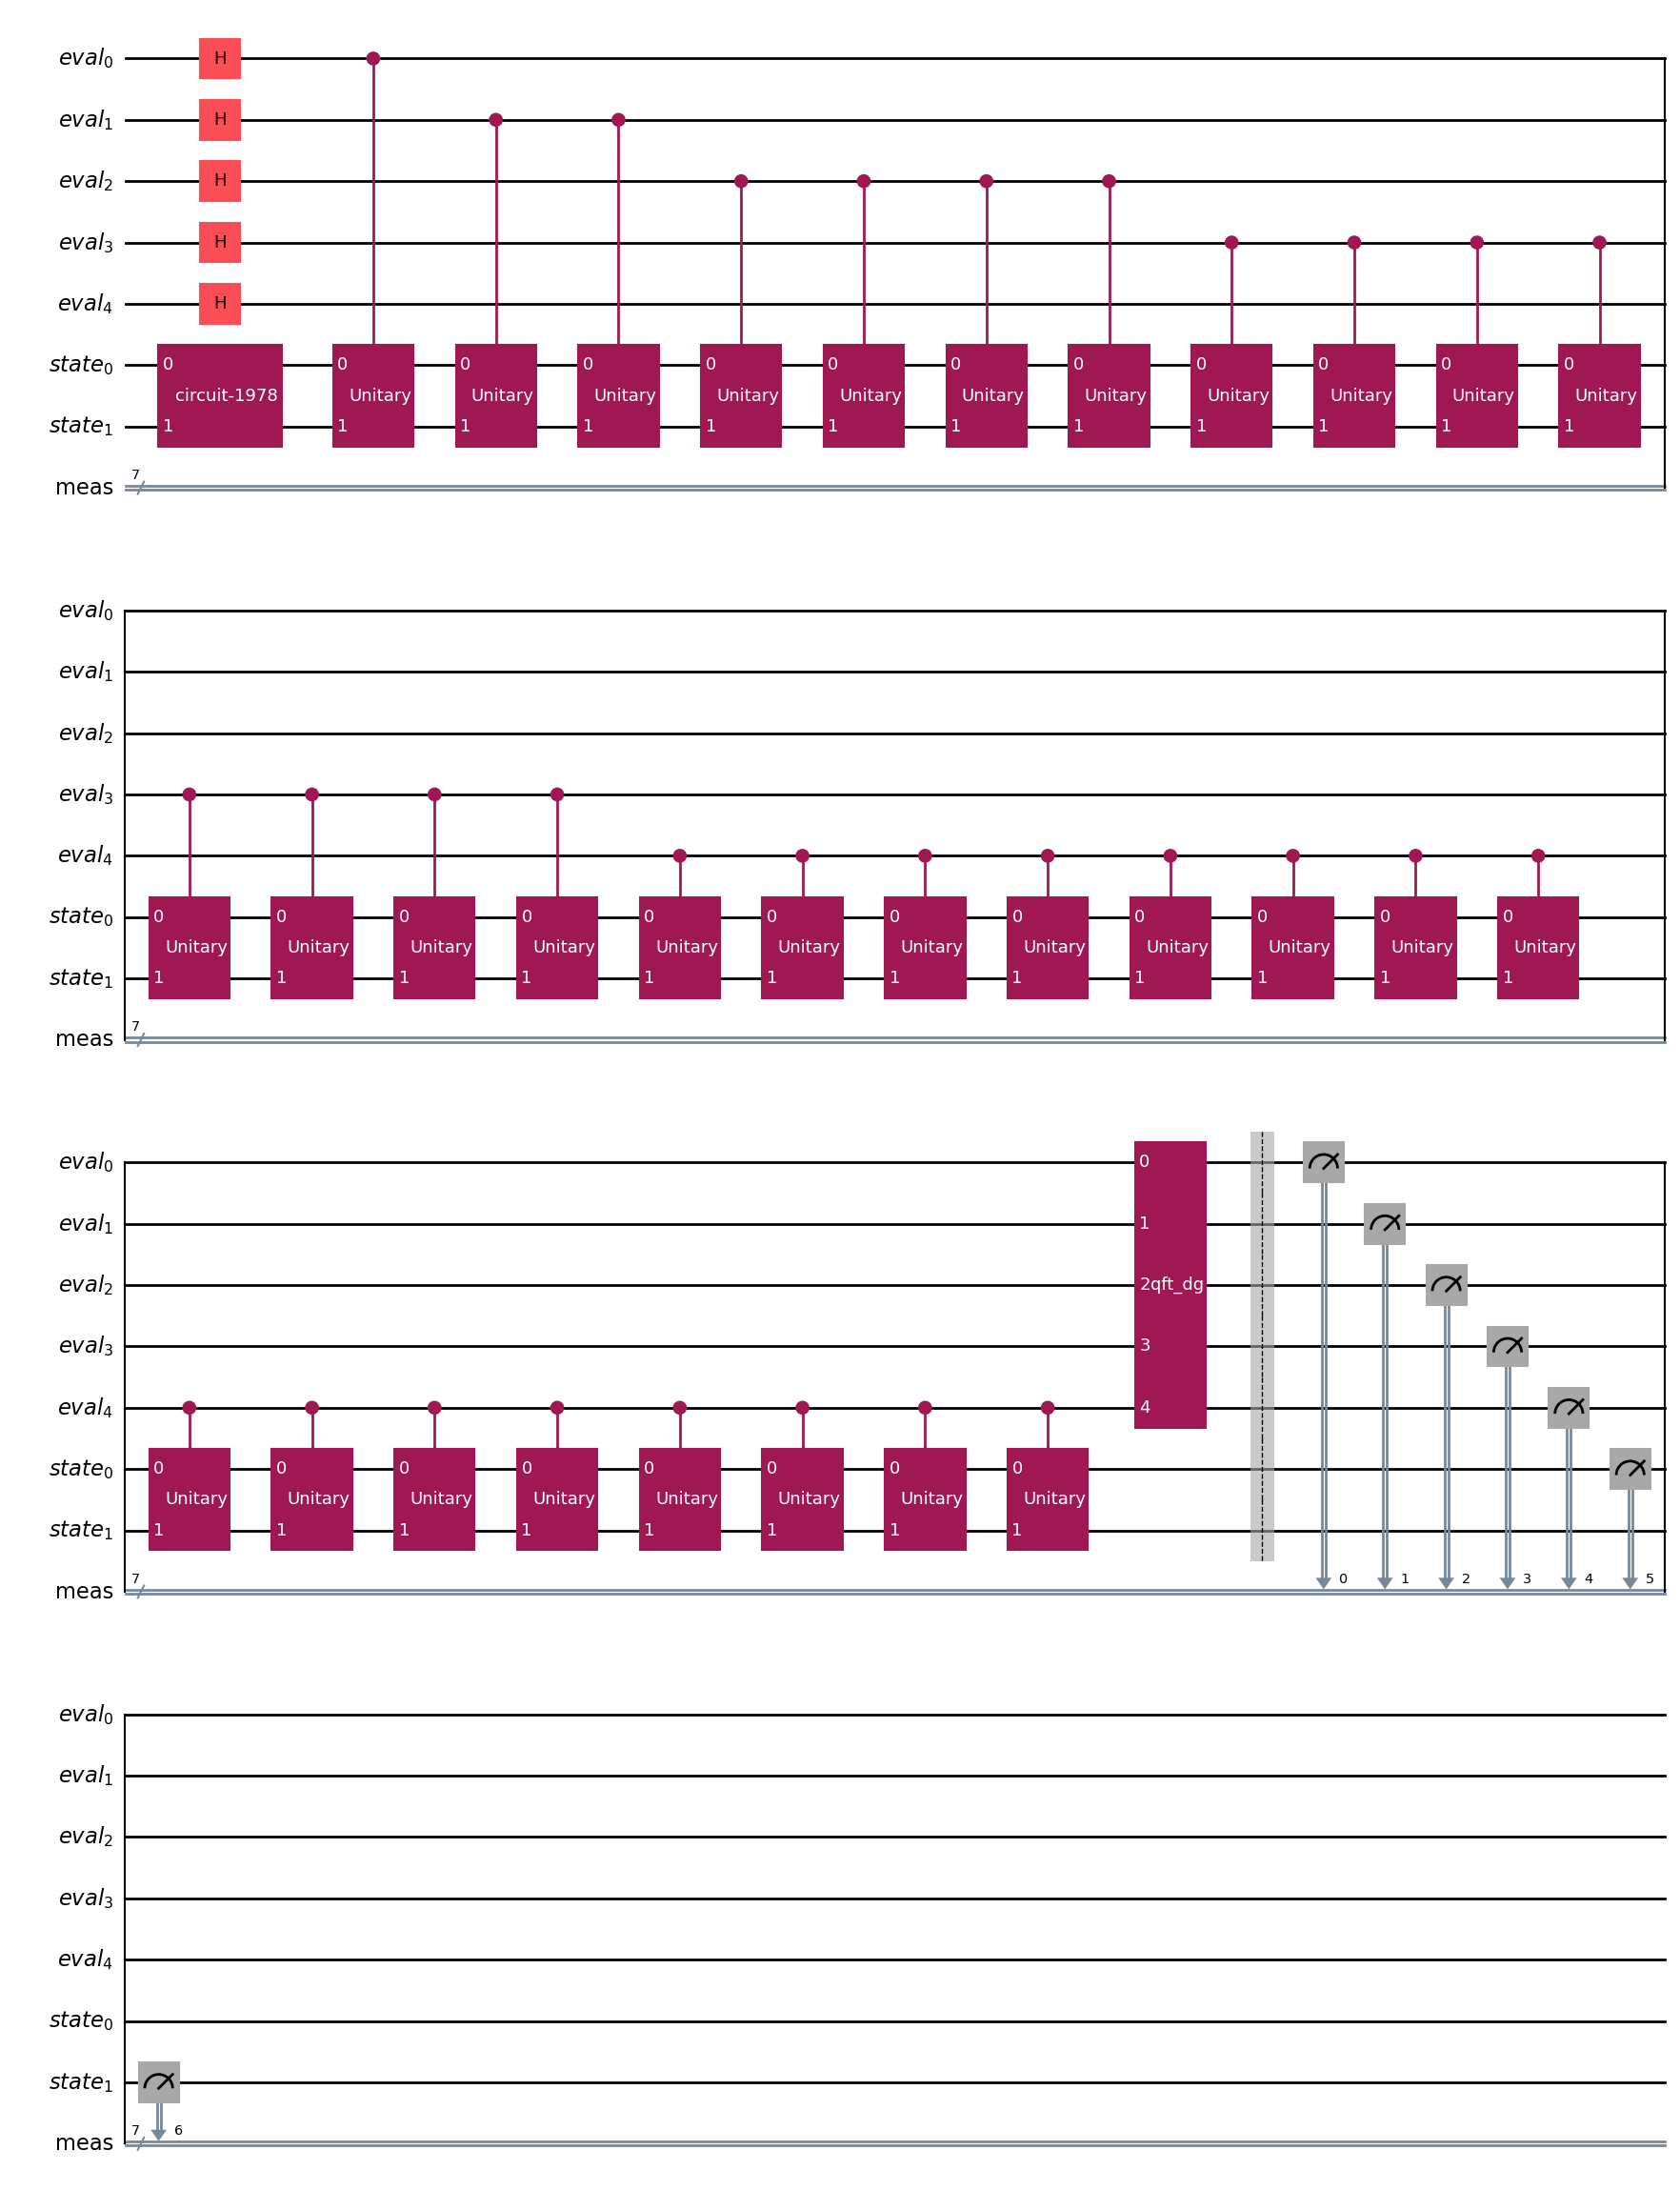

In [81]:
# Check that the circuit correctly estimates the eigenvalues 
# (only the states associated to the correct eigenvalues have probability amplitude different from 0)
# exact_statevector = check_statevector(backend,pe_circuit,resolution,example_matrix)
import pylatexenc
print("pylatexenc version:", pylatexenc.__version__)
pe_circuit.measure_all()
# print(exact_statevector)
#pe_circuit.decompose(reps=1).draw("mpl")

fig = visualize_quantum_circuit(pe_circuit.decompose(reps=1))
if fig is not None:
    display.display(fig) 

print(pe_circuit.draw('mpl'))


#### Quantum State Tomography

Total counts: 128
Max count value: 2396


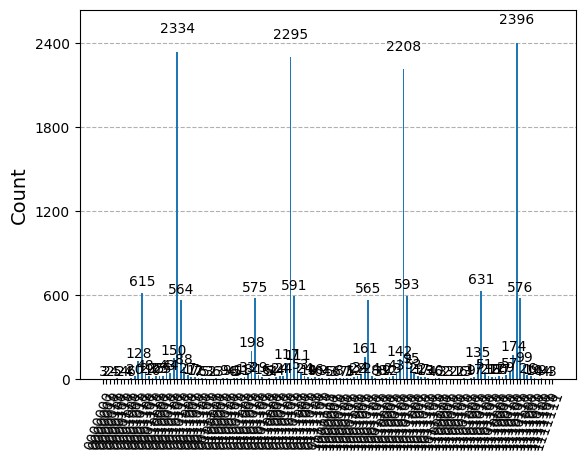

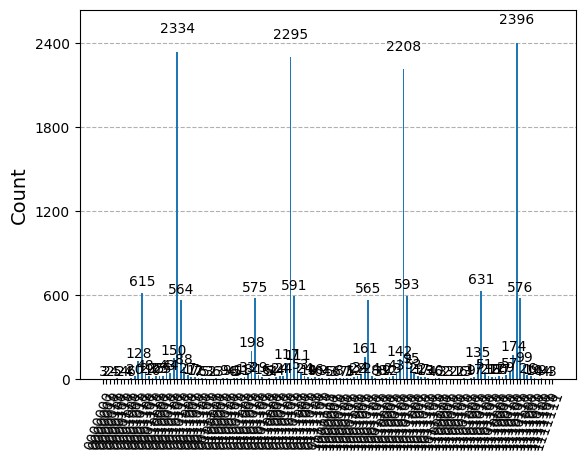

In [82]:
# Run the circuit using qiskit simulator
n_shots = 17000  # Increase to achieve higher accuracy

# Use AerSimulator from qiskit_aer instead of Aer.get_backend
from qiskit_aer import AerSimulator
backend_simulation = AerSimulator()  # Creates a QASM simulator by default

# Run the simulation (note: no "backend=" parameter needed)
job = backend_simulation.run(transpile(pe_circuit, backend_simulation), shots=n_shots)
counts = job.result().get_counts()
print("Total counts:", len(counts))
print("Max count value:", max(counts.values()) if counts else 0)

#so its not super crowded and ugly 
#filtered_counts = {k: v for k, v in counts.items() if v > 1000}
#plot_histogram(filtered_counts) 


# Visualize results if needed
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [83]:
# First, let's check what's actually in the counts dictionary
print("Example keys in counts:", list(counts.keys())[:3])
print("Format of first key:", [len(key.split()) for key in list(counts.keys())[:1]])

# Reconstruct probabilities directly since keys are already in the right format
probabilities = {}
for bitstring, count in counts.items():
    probabilities[bitstring] = count/n_shots

print("Number of non-zero entries:", len(probabilities))
print("Sum of probabilities:", sum(probabilities.values()))

# Ensure we have all bit strings in the probabilities dictionary
for i in range(2**pe_circuit.num_qubits):
    binary_i = bin(i)[2:].zfill(pe_circuit.num_qubits)
    if binary_i not in probabilities:
        probabilities[binary_i] = 0.0

# Normalize probabilities
norm_factor = sum(probabilities.values())
if norm_factor > 1e-10:
    probabilities = {k: v/norm_factor for k, v in probabilities.items()}
    print("After normalization, sum =", sum(probabilities.values()))

# Now proceed with sign estimation
sign_dictionary = sign_estimation(pe_circuit, probabilities, n_shots)






Example keys in counts: ['1100011', '1100100', '0111111']
Format of first key: [1]
Number of non-zero entries: 128
Sum of probabilities: 1.0
After normalization, sum = 1.0
Processing probabilities: 128
Sign dictionary entries: 128


#### Results

In [84]:
#print("Debug - Probabilities:", probabilities)
result = eigen_estimation(probabilities, sign_dictionary, resolution, debug=False)
#print("Raw eigen_estimation result:", result)
print("Quantum method results:")
result = eigen_estimation(probabilities, sign_dictionary, resolution, debug=False)
eigenvalues = []
eigenvectors = []
for eig, eigenvector in result:
    print(f'eigenvalue: {eig*norm_factor} - eigenvector: {np.real(eigenvector).round(3)}')
    eigenvalues.append(eig*norm_factor) #norm factor 
    eigenvectors.append(list(eigenvector))

print(f'eigenvalue: {eig} - eigenvector: {np.real(eigenvector).round(3)}')

[0.03985267 0.03910769 0.05530663 0.05583589]
10.372797920949813
[0.10116963 0.09393364 0.08295995 0.09139443]
5.3999555299611
[0.10792154 0.09731695 0.08911328 0.08677218]
5.227924034510346
[0.18214409 0.1840716  0.18645296 0.18676818]
2.7046208944035137
[0.04405878 0.03162278 0.03429972 0.04472136]
12.785207798918972
[0.36742346 0.36039194 0.37053221 0.37542133]
1.356916248246252
[0.18391174 0.19020113 0.1823055  0.19265941]
2.6692499362422186
[0.07194769 0.08080478 0.07631205 0.0747545 ]
6.577005204154147
[np.float64(0.4133836909571628)] [array([1.        , 0.98130676])]
[np.float64(0.4133836909571628), np.float64(0.5791744452016884)] [array([1.        , 0.98130676]), array([0.99052111, 1.        ])]
1
0.5791744452016884
[np.float64(0.5463115052059692)] [array([1.        , 0.92847669])]
[np.float64(0.5463115052059692), np.float64(0.4935258382311055)] [array([1.        , 0.92847669]), array([0.90771343, 1.        ])]
0
0.5463115052059692
[np.float64(0.5642056134748461)] [array([1.   

Quantum method results:
Raw eigen_estimation intermediate results: [('1100011', 0.00011764705882352942), ('1100100', 5.882352941176471e-05), ('0111111', 0.00023529411764705883), ('1100111', 0.00017647058823529413), ('1111111', 0.00017647058823529413), ('0100000', 0.00035294117647058826), ('0000010', 0.00011764705882352942), ('1100010', 0.00017647058823529413), ('0000101', 0.00011764705882352942), ('1011111', 0.00035294117647058826), ('1000110', 0.0002941176470588235), ('0000011', 0.00023529411764705883), ('0100101', 0.00035294117647058826), ('1010001', 0.0007058823529411765), ('0100011', 0.0005294117647058823), ('1100000', 0.00017647058823529413), ('0100100', 0.00023529411764705883), ('1111100', 0.0005294117647058823), ('1010000', 0.0005294117647058823), ('1000010', 0.00035294117647058826), ('0100110', 0.0002941176470588235), ('1111011', 0.00023529411764705883), ('0010000', 0.0013529411764705882), ('0011001', 0.001), ('1110011', 0.003352941176470588), ('0101111', 0.0002941176470588235)

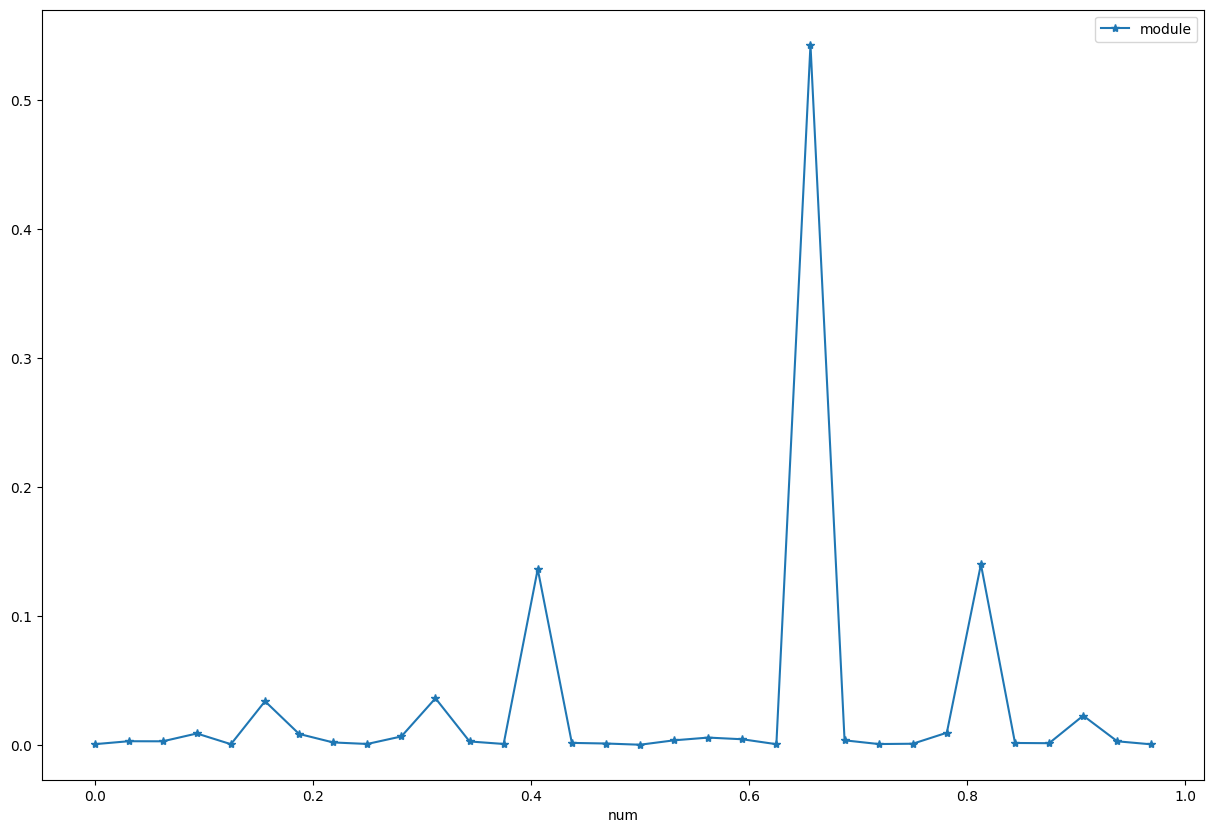

In [85]:
print("Quantum method results:")
result = eigen_estimation(probabilities, sign_dictionary, resolution, debug=True)
eigenvalues = []
eigenvectors = []
for eig, eigenvector in result:
    print(f'eigenvalue: {eig*norm_factor} - eigenvector: {np.real(eigenvector).round(3)}')
    eigenvalues.append(eig*norm_factor)
    eigenvectors.append(list(eigenvector))




#eigen_estimation
#print(f'eigenvalue: {eig} - eigenvector: {np.real(eigenvector).round(3)}')

In [86]:

original_matrix = example_matrix*norm_factor
reduced_matrix = transform(original_matrix, eigenvalues, eigenvectors)
reduced_matrix.round(3)


array([[-0.817, -1.224, -0.874, -0.742,  0.555, -0.582, -0.509, -0.213],
       [ 0.832, -1.18 , -0.83 , -0.743,  0.633, -0.585, -0.523,  0.269]])

In [87]:
# Select eigenvalues closest to 0 and 1 after rescaling
#selected_indices = [0, 2]  # Indices of values 0.0625 and 0.25 (which rescale to 0.25 and 1.0)

#selected_eigenvalues = [eigenvalues[i] for i in selected_indices]
#elected_eigenvectors = [eigenvectors[i] for i in selected_indices]

# Use these in your transform function
#reduced_matrix = transform(original_matrix, selected_eigenvalues, selected_eigenvectors)
#reduced_matrix

In [88]:

# Use the eigenvalues and eigenvectors directly
original_matrix = example_matrix*norm_factor
reduced_matrix = transform(original_matrix, selected_eigenvalues, selected_eigenvectors)
reduced_matrix.round(3)

NameError: name 'selected_eigenvalues' is not defined

In [ ]:
# Define your target classical eigenvalues
target_values = [0, 1]  # Classical eigenvalues


# Filter eigenvalues 
def filter_eigenvalues_by_target(eigenvalues, eigenvectors, target_values):
    import numpy as np
    
    filtered_eigenvalues = []
    filtered_eigenvectors = []
    
    # For each target value, find the closest eigenvalue
    for target in target_values:
        distances = [abs(ev - target) for ev in eigenvalues]
        closest_idx = np.argmin(distances)
        
        filtered_eigenvalues.append(eigenvalues[closest_idx])
        filtered_eigenvectors.append(eigenvectors[closest_idx])
    
    return filtered_eigenvalues, filtered_eigenvectors

# Apply the filtering
filtered_eigenvalues, filtered_eigenvectors = filter_eigenvalues_by_target(
    eigenvalues, eigenvectors, target_values)

# Print the filtered results
print("Filtered quantum eigenvalues and eigenvectors:")
for ev, evec in zip(filtered_eigenvalues, filtered_eigenvectors):
    print(f"eigenvalue: {ev} - eigenvector: {np.real(np.array(evec)).round(3)}")

# Align eigenvector signs with classical
classical_eigenvectors = [[-0.707, 0.707], [0.707, 0.707]]
for i in range(len(filtered_eigenvectors)):
    # Need to flip second component of quantum eigenvectors to match classical
    filtered_eigenvectors[i][1] = -filtered_eigenvectors[i][1]
    
    # Check dot product to ensure alignment
    dot_product = np.dot(np.real(filtered_eigenvectors[i]), classical_eigenvectors[i])
    if dot_product < 0:
        filtered_eigenvectors[i] = [-x for x in filtered_eigenvectors[i]]

# Use these filtered values with your transform function
reduced_matrix = transform(original_matrix, filtered_eigenvalues, filtered_eigenvectors)
print("Transformed matrix using filtered eigenvalues:")
print(reduced_matrix.round(4))



NameError: name 'eigenvalues' is not defined

In [486]:
original_matrix = example_matrix*norm_factor
reduced_matrix = transform(original_matrix, eigenvalues, eigenvectors)
reduced_matrix.round(3)


#Sort eigenvalues and keep top 2 only for 2x2 as its trying to make a 2x3 
#sorted_results = sorted(zip(eigenvalues, eigenvectors), key=lambda x: x[0], reverse=True)
#top_eigenvalues = [sorted_results[0][0], sorted_results[1][0]]
#op_eigenvectors = [sorted_results[0][1], sorted_results[1][1]]

# Transform using only top 2 components
#reduced_matrix = transform(original_matrix, top_eigenvalues, top_eigenvectors)
#print("Reduced matrix with top 2 components:\n", reduced_matrix.round(3))





array([[ 1.942,  1.345, -0.826,  0.254, -0.773,  0.673,  0.548, -0.6  ,
        -0.552,  0.557,  0.508],
       [ 1.981,  1.112, -0.982, -0.519, -0.769,  0.577,  0.616, -0.595,
        -0.519,  0.526,  0.523]])

In [487]:
def filter_eigenvalues_by_target(eigenvalues, eigenvectors, target_values):
    """
    Filter eigenvalues/eigenvectors to match specific target values
    
    Parameters:
    -----------
    eigenvalues : list
        List of eigenvalues from quantum estimation
    eigenvectors : list
        List of eigenvectors corresponding to eigenvalues
    target_values : list
        Target eigenvalues to match (e.g., [0, 1])
    
    Returns:
    --------
    filtered_eigenvalues : list
        List of filtered eigenvalues closest to targets
    filtered_eigenvectors : list
        Corresponding eigenvectors
    """
    import numpy as np
    
    filtered_eigenvalues = []
    filtered_eigenvectors = []
    
    # For each target value, find the closest eigenvalue
    for target in target_values:
        distances = [abs(ev - target) for ev in eigenvalues]
        closest_idx = np.argmin(distances)
        
        filtered_eigenvalues.append(eigenvalues[closest_idx])
        filtered_eigenvectors.append(eigenvectors[closest_idx])
    
    return filtered_eigenvalues, filtered_eigenvectors

# Use with your quantum results
target_values = [0, 1]  # Classical eigenvalues
filtered_eigenvalues, filtered_eigenvectors = filter_eigenvalues_by_target(
    eigenvalues, eigenvectors, target_values)

In [ ]:
#Trying to deubug this situation no longer use this section
# After running your eigen_estimation with any resolution (e.g., 3 or 5)
result = eigen_estimation(probabilities, sign_dictionary, resolution, debug=False)
eigenvalues = []
eigenvectors = []
for eig, eigenvector in result:
    eigenvalues.append(eig*norm_factor)
    eigenvectors.append(list(eigenvector))

# Now filter to get exactly matrix_dimension eigenvalues
matrix_dimension = 2  # For a 2x2 matrix
filtered_eigenvalues, filtered_eigenvectors = filter_eigenvalues(eigenvalues, eigenvectors, matrix_dimension, resolution)

# Use filtered values for transformation
reduced_matrix = transform(original_matrix, filtered_eigenvalues, filtered_eigenvectors)
reduced_matrix.round(3)



array([[ 0.243,  0.942],
       [-0.272, -1.02 ]])

Note: 

1) The signs of the eigenvectors are arbitrary. 
You can flip them without changing the meaning of ther result; only their direction matters.

2) One can improve the accuracy of the algorithm increasing the *resolution* parameter and the number of shots

In [489]:
print("Classically computed values:")
zipped_list = list(zip(np.linalg.eig(original_matrix)[0][::-1], np.rot90(np.linalg.eig(original_matrix)[1])))
cl_eigenvalues = []
cl_eigenvectors = []
for eigenval, eigenvec in sorted(zipped_list, key = lambda x: x[0]):
    print(f'eigenvalue: {eigenval:.0f} - eigenvector: {eigenvec.round(3)}')
    cl_eigenvalues.append(eigenval)
    cl_eigenvectors.append(list(eigenvec))

Classically computed values:
eigenvalue: 0 - eigenvector: [-0.707  0.707]
eigenvalue: 1 - eigenvector: [0.707 0.707]


In [490]:
classically_reduced_matrix = transform(original_matrix, cl_eigenvalues, cl_eigenvectors)
classically_reduced_matrix.round(3)


array([[-0.408,  0.577],
       [ 0.408,  0.577]])

In [491]:
# Classical eigenvalues and eigenvectors
#cl_eigenvalues = [0, 1]
#cl_eigenvectors = [[-0.707, 0.707], [0.707, 0.707]]

# Use the reconstruct_matrix function with classical values
#classical_reconstructed = reconstruct_matrix(cl_eigenvalues, cl_eigenvectors)
#print("Reconstructed matrix from classical eigenvalues and eigenvectors:")
#print(classical_reconstructed.round(3))